In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('resume screening.csv')
df

,skill_match_ratio,experience_gap,keyword_overlap,resume_length,certification_score,education_level,job_domain,relevance_score
0,0.615635,0.644163,0.835155,699.874580,5,Masters,Education,91.312554
1,0.499997,-2.138718,0.884179,324.660593,2,Masters,Marketing,65.129014
2,0.618608,-0.621854,0.539711,497.985137,1,Masters,Healthcare,72.148019
3,0.314110,-2.073988,0.861731,622.063750,3,Bachelors,Finance,65.397425
4,0.902516,-0.751196,0.850092,768.340223,5,Diploma,Education,100.000000
...,...,...,...,...,...,...,...,...
29995,0.413153,-2.489760,0.380714,593.002474,1,Bachelors,IT,42.632682
29996,0.451852,4.543030,0.266727,284.905311,0,Bachelors,IT,34.540215
29997,0.307167,1.815533,0.817778,642.000875,0,Masters,IT,47.883435
29998,0.664304,1.661141,0.501879,597.474052,0,Bachelors,Marketing,49.101200


In [3]:
df.head()

,skill_match_ratio,experience_gap,keyword_overlap,resume_length,certification_score,education_level,job_domain,relevance_score
0,0.615635,0.644163,0.835155,699.874580,5,Masters,Education,91.312554
1,0.499997,-2.138718,0.884179,324.660593,2,Masters,Marketing,65.129014
2,0.618608,-0.621854,0.539711,497.985137,1,Masters,Healthcare,72.148019
3,0.314110,-2.073988,0.861731,622.063750,3,Bachelors,Finance,65.397425
4,0.902516,-0.751196,0.850092,768.340223,5,Diploma,Education,100.000000


In [4]:
df.tail()

,skill_match_ratio,experience_gap,keyword_overlap,resume_length,certification_score,education_level,job_domain,relevance_score
29995,0.413153,-2.489760,0.380714,593.002474,1,Bachelors,IT,42.632682
29996,0.451852,4.543030,0.266727,284.905311,0,Bachelors,IT,34.540215
29997,0.307167,1.815533,0.817778,642.000875,0,Masters,IT,47.883435
29998,0.664304,1.661141,0.501879,597.474052,0,Bachelors,Marketing,49.101200
29999,0.098252,-1.631225,0.721422,571.774948,0,Masters,Marketing,30.055249


In [5]:
df.shape

(30000, 8)

In [6]:
df.size

240000

In [7]:
df.columns

Index(['skill_match_ratio', 'experience_gap', 'keyword_overlap',
       'resume_length', 'certification_score', 'education_level', 'job_domain',
       'relevance_score'],
      dtype='object')

In [8]:
df.dtypes

skill_match_ratio      float64
experience_gap         float64
keyword_overlap        float64
resume_length          float64
certification_score      int64
education_level         object
job_domain              object
relevance_score        float64
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   skill_match_ratio    30000 non-null  float64
 1   experience_gap       30000 non-null  float64
 2   keyword_overlap      30000 non-null  float64
 3   resume_length        30000 non-null  float64
 4   certification_score  30000 non-null  int64  
 5   education_level      30000 non-null  object 
 6   job_domain           30000 non-null  object 
 7   relevance_score      30000 non-null  float64
dtypes: float64(5), int64(1), object(2)
memory usage: 1.8+ MB


In [10]:
df.isnull().sum()

skill_match_ratio      0
experience_gap         0
keyword_overlap        0
resume_length          0
certification_score    0
education_level        0
job_domain             0
relevance_score        0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.select_dtypes(include=['number'])

,skill_match_ratio,experience_gap,keyword_overlap,resume_length,certification_score,relevance_score
0,0.615635,0.644163,0.835155,699.874580,5,91.312554
1,0.499997,-2.138718,0.884179,324.660593,2,65.129014
2,0.618608,-0.621854,0.539711,497.985137,1,72.148019
3,0.314110,-2.073988,0.861731,622.063750,3,65.397425
4,0.902516,-0.751196,0.850092,768.340223,5,100.000000
...,...,...,...,...,...,...
29995,0.413153,-2.489760,0.380714,593.002474,1,42.632682
29996,0.451852,4.543030,0.266727,284.905311,0,34.540215
29997,0.307167,1.815533,0.817778,642.000875,0,47.883435
29998,0.664304,1.661141,0.501879,597.474052,0,49.101200


In [13]:
df.select_dtypes(include=['object'])

,education_level,job_domain
0,Masters,Education
1,Masters,Marketing
2,Masters,Healthcare
3,Bachelors,Finance
4,Diploma,Education
...,...,...
29995,Bachelors,IT
29996,Bachelors,IT
29997,Masters,IT
29998,Bachelors,Marketing


In [14]:
df['education_level'].unique()

array(['Masters', 'Bachelors', 'Diploma', 'PhD'], dtype=object)

In [15]:
df['job_domain'].unique()

array(['Education', 'Marketing', 'Healthcare', 'Finance', 'IT'],
      dtype=object)

In [16]:
df['education_level'].value_counts()

education_level
Bachelors    13504
Masters       9054
Diploma       4515
PhD           2927
Name: count, dtype: int64

In [17]:
df['job_domain'].value_counts()

job_domain
Healthcare    6058
Finance       6029
Education     5998
Marketing     5965
IT            5950
Name: count, dtype: int64

In [18]:
df.describe()

,skill_match_ratio,experience_gap,keyword_overlap,resume_length,certification_score,relevance_score
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.500841,-0.003514,0.502749,558.216901,2.515567,60.393924
std,0.223095,2.299614,0.222768,157.977175,1.703170,15.667930
min,0.001511,-30.507453,0.000670,70.358241,0.000000,0.000000
25%,0.326753,-1.346777,0.331207,469.333712,1.000000,49.531473
50%,0.502156,0.001285,0.504985,550.390840,3.000000,60.480744
75%,0.672984,1.352926,0.675871,632.044585,4.000000,71.489609
max,0.998030,29.040577,0.998585,2739.055453,5.000000,100.000000


In [19]:
data=df.select_dtypes(include=['number'])
data.corr()

,skill_match_ratio,experience_gap,keyword_overlap,resume_length,certification_score,relevance_score
skill_match_ratio,1.000000,0.002015,0.004629,-0.010707,-0.009891,0.534971
experience_gap,0.002015,1.000000,-0.010250,0.002155,-0.013390,-0.000645
keyword_overlap,0.004629,-0.010250,1.000000,-0.001903,-0.000816,0.371108
resume_length,-0.010707,0.002155,-0.001903,1.000000,-0.000823,-0.030715
certification_score,-0.009891,-0.013390,-0.000816,-0.000823,1.000000,0.639905
relevance_score,0.534971,-0.000645,0.371108,-0.030715,0.639905,1.000000


<Axes: >

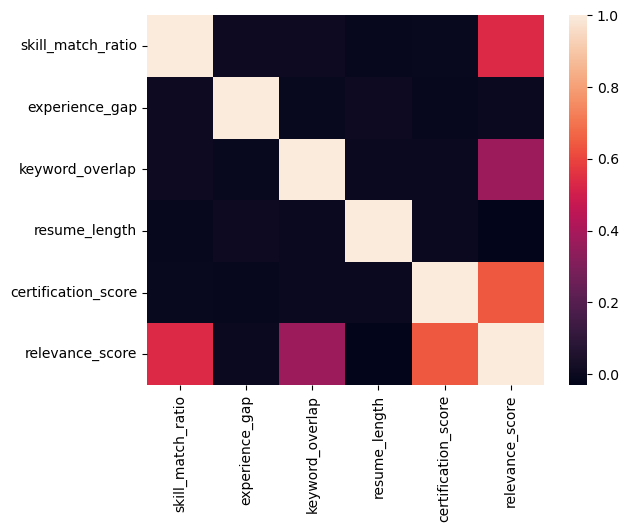

In [20]:
sns.heatmap(data.corr())

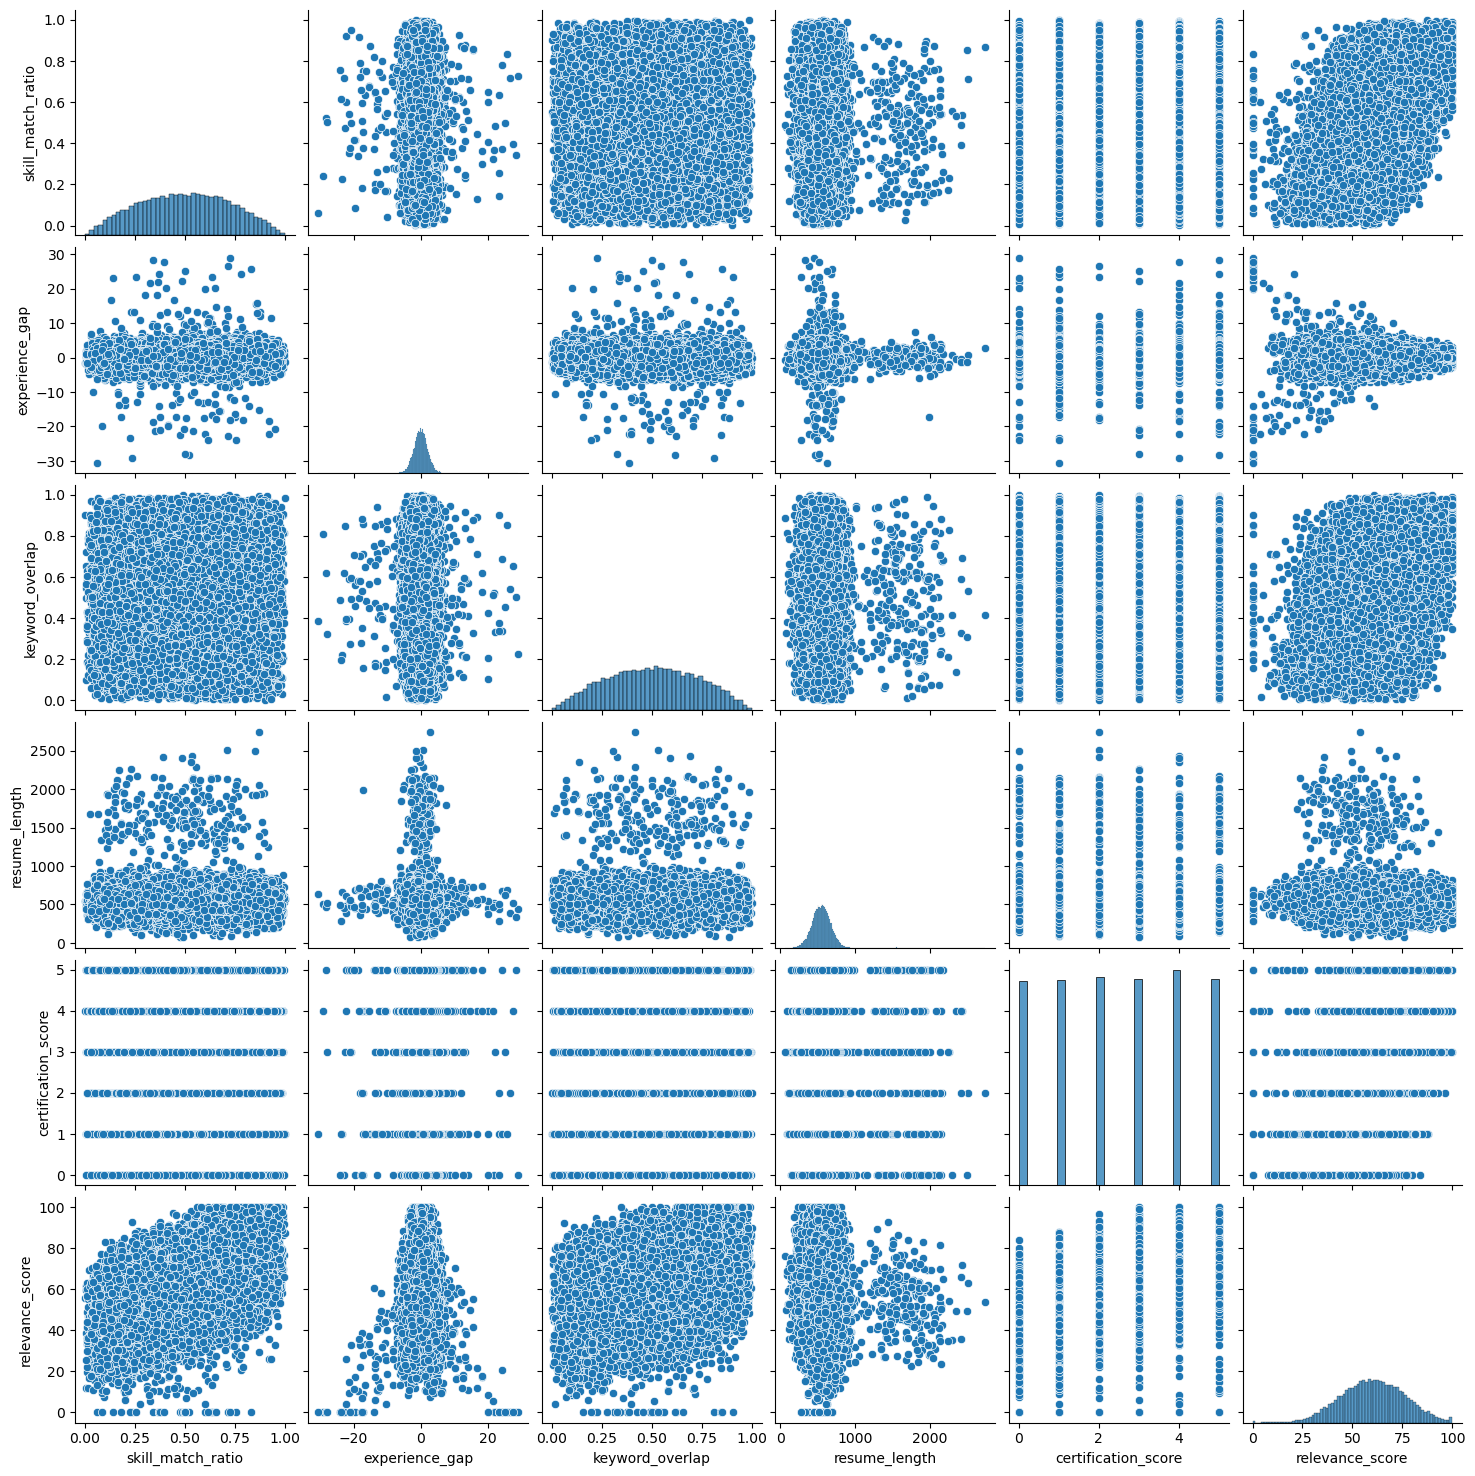

In [21]:
sns.pairplot(df)
plt.show()

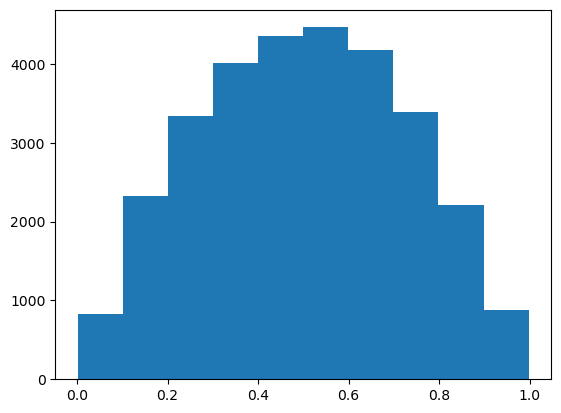

In [22]:
x=df['skill_match_ratio']
plt.hist(x)
plt.show()

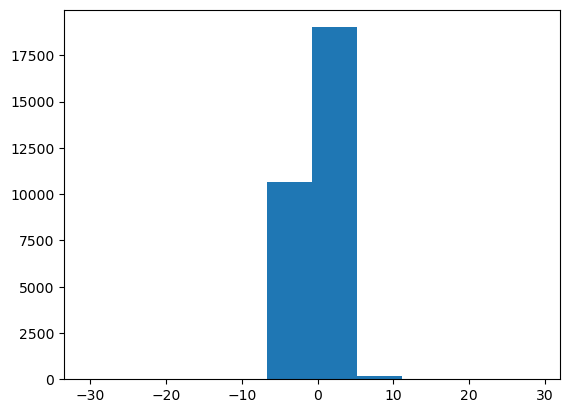

In [23]:
x=df['experience_gap']
plt.hist(x)
plt.show()

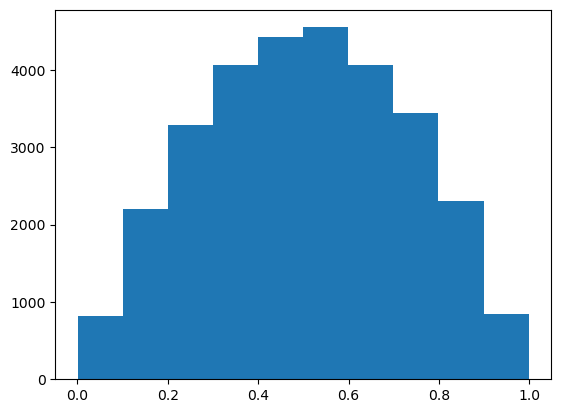

In [24]:
x=df['keyword_overlap']
plt.hist(x)
plt.show()

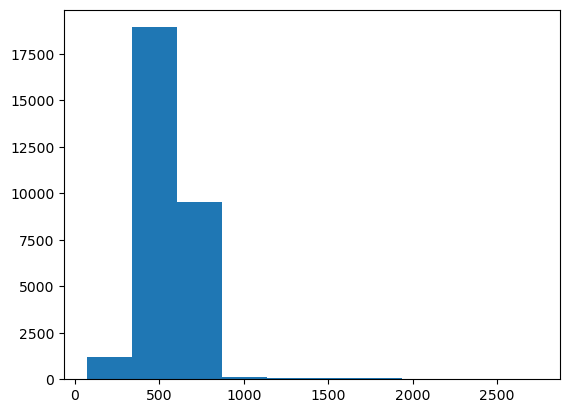

In [25]:
x=df['resume_length']
plt.hist(x)
plt.show()

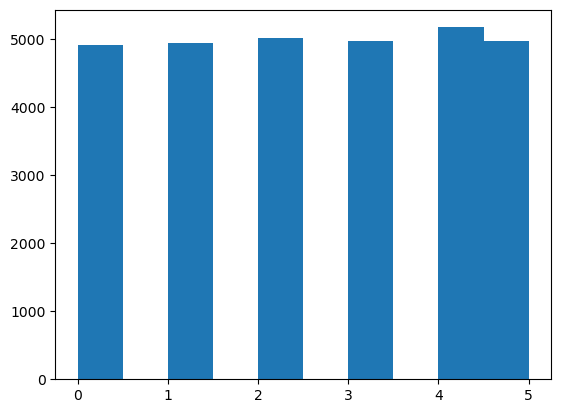

In [26]:
x=df['certification_score']
plt.hist(x)
plt.show()

<Axes: >

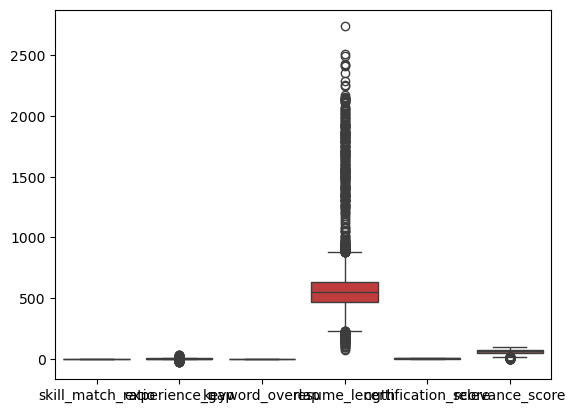

In [27]:
sns.boxplot(data)

<Axes: ylabel='experience_gap'>

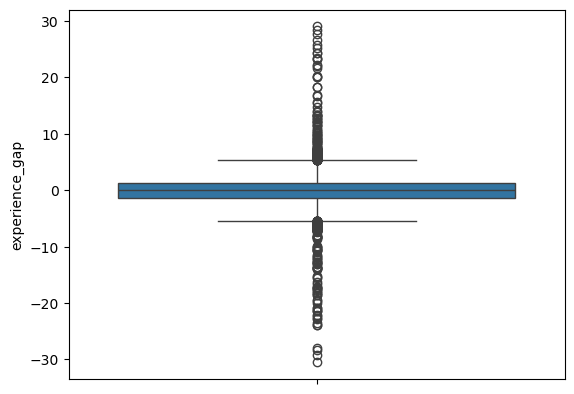

In [28]:
sns.boxplot(data['experience_gap'])

In [29]:
Q1=data['experience_gap'].quantile(0.25)
Q3=data['experience_gap'].quantile(0.75)
Q1,Q3

(np.float64(-1.3467768224514278), np.float64(1.3529259041845574))

In [30]:
IQR=Q3-Q1
IQR

np.float64(2.6997027266359854)

In [31]:
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
lower_limit,upper_limit

(np.float64(-5.396330912405406), np.float64(5.4024799941385355))

In [32]:
new_data=data.copy()
new_data.loc[(new_data['experience_gap']>=upper_limit),'experience_gap']=upper_limit
new_data.loc[(new_data['experience_gap']<=lower_limit),'experience_gap']=lower_limit

<Axes: ylabel='experience_gap'>

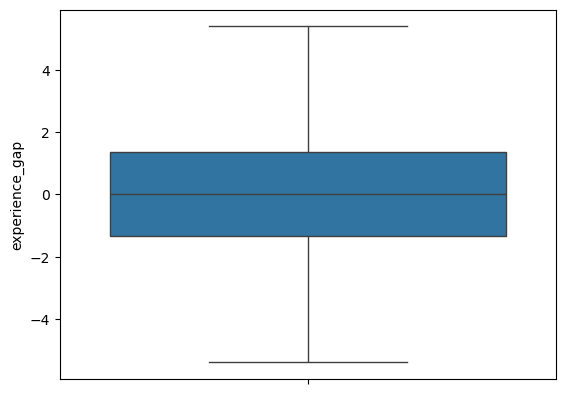

In [33]:
sns.boxplot(new_data['experience_gap'])

<Axes: ylabel='resume_length'>

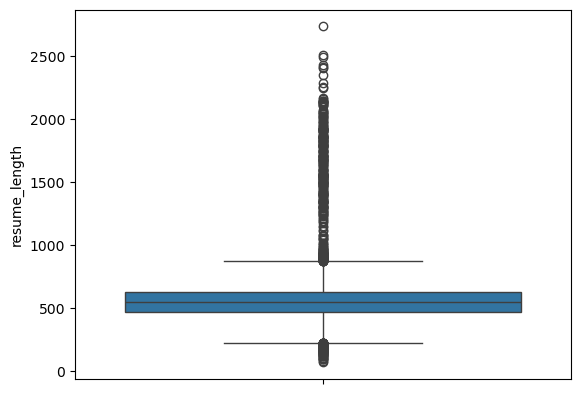

In [34]:
sns.boxplot(new_data['resume_length'])

In [35]:
Q1=data['resume_length'].quantile(0.25)
Q3=data['resume_length'].quantile(0.75)
Q1,Q3

(np.float64(469.33371235366906), np.float64(632.044584907975))

In [36]:
IQR=Q3-Q1
IQR

np.float64(162.71087255430598)

In [37]:
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
lower_limit,upper_limit

(np.float64(225.2674035222101), np.float64(876.110893739434))

In [38]:
new_data.loc[(new_data['resume_length']>=upper_limit),'resume_length']=upper_limit
new_data.loc[(new_data['resume_length']<=lower_limit),'resume_length']=lower_limit

<Axes: ylabel='resume_length'>

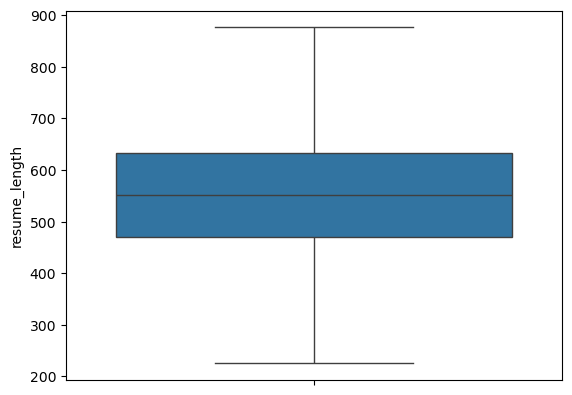

In [39]:
sns.boxplot(new_data['resume_length'])

In [40]:
from sklearn.preprocessing import LabelEncoder
le1=LabelEncoder()
df['education_level']=le1.fit_transform(df['education_level'])
le2=LabelEncoder()
df['job_domain']=le2.fit_transform(df['job_domain'])
df

,skill_match_ratio,experience_gap,keyword_overlap,resume_length,certification_score,education_level,job_domain,relevance_score
0,0.615635,0.644163,0.835155,699.874580,5,2,0,91.312554
1,0.499997,-2.138718,0.884179,324.660593,2,2,4,65.129014
2,0.618608,-0.621854,0.539711,497.985137,1,2,2,72.148019
3,0.314110,-2.073988,0.861731,622.063750,3,0,1,65.397425
4,0.902516,-0.751196,0.850092,768.340223,5,1,0,100.000000
...,...,...,...,...,...,...,...,...
29995,0.413153,-2.489760,0.380714,593.002474,1,0,3,42.632682
29996,0.451852,4.543030,0.266727,284.905311,0,0,3,34.540215
29997,0.307167,1.815533,0.817778,642.000875,0,2,3,47.883435
29998,0.664304,1.661141,0.501879,597.474052,0,0,4,49.101200


In [41]:
x = df.drop('relevance_score', axis=1)
y = df['relevance_score']

In [42]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)

In [43]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
sd= StandardScaler()
x_train=sd.fit_transform(x_train)
x_test=sd.transform(x_test)
x_test

array([[-2.42100322e-01,  3.88370800e-01,  1.90381712e+00, ...,
        -1.47865711e+00, -9.83030993e-01,  1.41387482e+00],
       [-3.39849222e-01, -1.49523406e-01,  1.58375537e-01, ...,
         8.68728169e-01, -9.83030993e-01, -3.24087249e-04],
       [-6.04865394e-01,  2.34753597e-01,  5.24319974e-01, ...,
        -8.91810790e-01, -9.83030993e-01,  1.41387482e+00],
       ...,
       [-1.23318111e+00,  1.60837052e+00, -1.44410305e+00, ...,
        -8.91810790e-01, -9.83030993e-01, -7.07423540e-01],
       [-7.42347464e-01, -1.86979015e-01, -1.78044043e+00, ...,
         2.81881849e-01, -9.83030993e-01, -3.24087249e-04],
       [ 1.04378764e+00, -9.74649653e-01,  6.84002320e-01, ...,
        -1.47865711e+00, -9.83030993e-01,  7.06775365e-01]])

In [44]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=5)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.fit_transform(x_test)

In [45]:
from sklearn.linear_model import LinearRegression
mlr= LinearRegression()
mlr.fit(x_train_poly,y_train)
y_pred=mlr.predict(x_test_poly)

In [46]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print(mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

3.8516115074852704
10.232857933448654


In [47]:
print('cofficient:',mlr.coef_)
print('intercept',mlr.intercept_)

cofficient: [-2.11859018e-14  8.62479136e+00  3.91382875e-01  5.96929909e+00
  1.95990562e-01  1.05736920e+01  1.83232310e+00  4.17536846e-01
  1.31926417e-01 -3.26850184e-02  5.45545776e-02  9.72306600e-02
  1.75325821e-01 -1.15342118e-01  3.95805230e-02 -2.53531548e+00
  2.52355603e-01  3.17886977e-01  6.44438318e-02  6.63223289e-02
  2.44589639e-01  2.86102578e-01  3.22975381e-02  3.06216918e-02
 -8.77797448e-02  2.55928305e-01 -3.12718876e-01 -2.24235407e-02
 -1.17407835e-01 -8.83531520e-02  1.47235617e-01 -1.87591283e-01
 -2.68323693e-01  2.47688109e+00  1.09577868e-01  2.07377442e+00
  8.17342413e-02 -1.38698426e-01 -8.64207629e-02 -1.01174326e-02
 -1.63061793e-01 -1.28164574e-01 -2.63088894e-03 -2.98874830e-01
 -6.26965531e-02 -1.39033290e-02  9.81059355e-02 -1.86633157e-01
  8.82340817e-02 -2.24121111e-02  1.78409335e-01  1.77322914e-02
 -9.77385856e-02  2.57043567e-03  6.41966820e-02  1.71133875e-01
  1.12648927e-01  1.17338554e-01 -3.42775062e-02 -1.77927051e-02
  2.05258753e

In [48]:
print(r2_score(y_test,y_pred))

0.5755992865543447


In [49]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
y_pred

array([53.70277763, 66.12702807, 48.47111489, ..., 31.65256901,
       45.68875831, 57.50201388])

In [50]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np
print(mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

4.561352218764783
6.384838716194545


In [51]:
print('cofficient:',lr.coef_)
print('intercept',lr.intercept_)

cofficient: [ 8.4421713   0.05269316  5.80252196 -0.38088447 10.10942675  1.03698956
  0.07451194]
intercept 60.36208798892681


In [52]:
print(r2_score(y_test,y_pred))

0.8347725963677004


In [53]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(n_neighbors=3)
knn.fit(x_train,y_train)

KNeighborsRegressor(n_neighbors=3)

In [54]:
y_pred=knn.predict(x_test)
print( mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

4.41882765955507
5.589118565763718


In [55]:
print(r2_score(y_test,y_pred))

0.8733897514649804


In [56]:
print("training score:",knn.score(x_train,y_train))
print("test score:",knn.score(x_test,y_test))

training score: 0.9359781423795875
test score: 0.8733897514649804


In [57]:
from sklearn.svm import SVR               
svr=SVR()                                  
svr.fit(x_train,y_train)
y_prd=svr.predict(x_test)
y_prd

array([54.96906719, 70.93636929, 51.02201542, ..., 25.92370316,
       49.22042831, 56.9481743 ])

In [58]:
print("training score:",svr.score(x_train,y_train))
print("test score:",svr.score(x_test,y_test))

training score: 0.9132563831024968
test score: 0.9015746977862097


In [59]:
print(mean_absolute_error(y_test,y_prd))
print(np.sqrt(mean_squared_error(y_test,y_prd)))

3.5612888632842115
4.927904360067876


In [60]:
print(r2_score(y_test,y_pred))

0.8733897514649804


In [61]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
ridge=Ridge(alpha=0.1)
ridge.fit(x_train,y_train)
y_pred=ridge.predict(x_test)

In [62]:
print( mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

4.561352822594478
6.384839412972251


In [63]:
print(r2_score(y_test,y_pred))

0.834772560305152


In [64]:
lasso=Lasso(alpha=1)
lasso.fit(x_train,y_train)
y_pred=lasso.predict(x_test)

In [65]:
print( mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

4.858492617571946
6.711934888721557


In [66]:
print(r2_score(y_test,y_pred))

0.8174097069832609


In [67]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(random_state=42)
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)

In [68]:
print( mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

5.250091941451387
6.805326845907993


In [69]:
print(r2_score(y_test,y_pred))

0.8122931193607491


In [70]:
from sklearn.ensemble import RandomForestRegressor
rf= RandomForestRegressor(random_state=42)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)

In [71]:
print( mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

3.770199105783574
5.013366637819459


In [72]:
print(r2_score(y_test,y_pred))

0.8981312096409737


In [73]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [74]:
adaboost=AdaBoostRegressor(n_estimators=50,  estimator=None, learning_rate=0.3,random_state=1)
adaboost.fit(x_train,y_train)

AdaBoostRegressor(learning_rate=0.3, random_state=1)

In [75]:
y_pred=adaboost.predict(x_test)
y_pred

array([51.67602656, 68.85744612, 44.98840084, ..., 38.76663854,
       53.24877336, 58.78288704])

In [76]:
print( mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

6.365441685129653
8.12008783753781


In [77]:
print(r2_score(y_test,y_pred))

0.732758641834904


In [78]:
gbc=GradientBoostingRegressor(n_estimators=54,learning_rate=0.5,random_state=3)
gbc.fit(x_train,y_train)

GradientBoostingRegressor(learning_rate=0.5, n_estimators=54, random_state=3)

In [79]:
y_pred=adaboost.predict(x_test)
y_pred

array([51.67602656, 68.85744612, 44.98840084, ..., 38.76663854,
       53.24877336, 58.78288704])

In [80]:
print( mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

6.365441685129653
8.12008783753781


In [81]:
print(r2_score(y_test,y_pred))

0.732758641834904


In [82]:
model= XGBRegressor()
model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [83]:
y_pred=adaboost.predict(x_test)
y_pred

array([51.67602656, 68.85744612, 44.98840084, ..., 38.76663854,
       53.24877336, 58.78288704])

In [84]:
print( mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

6.365441685129653
8.12008783753781


In [85]:
print(r2_score(y_test,y_pred))

0.732758641834904


In [86]:
from sklearn.model_selection import train_test_split,GridSearchCV
param={'n_neighbors':[3,5,7,9],'weights':['uniform','distance']}
grid=GridSearchCV(knn,param,cv=10,scoring='r2')
grid.fit(x_train,y_train)

GridSearchCV(cv=10, estimator=KNeighborsRegressor(n_neighbors=3),
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']},
             scoring='r2')

In [87]:
print(grid.best_params_)

{'n_neighbors': 9, 'weights': 'distance'}


In [88]:
y_pred=grid.predict(x_test)
print( mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

3.954593641527904
5.038765999997569


In [89]:
print(r2_score(y_test,y_pred))

0.897096393397378


In [90]:
print("training score:",grid.score(x_train,y_train))
print("test score:",grid.score(x_test,y_test))

training score: 1.0
test score: 0.897096393397378


In [91]:
lasso = Lasso(max_iter=10000)
param_grid = {'alpha': [ 0.001, 0.01, 0.1, 1]}
grid_lasso = GridSearchCV(lasso,param_grid, cv=5,scoring='r2')
grid_lasso.fit(x_train, y_train)
print(grid_lasso.best_params_)

{'alpha': 0.01}


In [92]:
y_pred=grid_lasso.predict(x_test)
print( mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

4.561555940203946
6.3859686071452


In [93]:
print(r2_score(y_test,y_pred))

0.8347141123635968


In [94]:
print("training score:",grid_lasso .score(x_train,y_train))
print("test score:",grid_lasso .score(x_test,y_test))

training score: 0.8460954364690174
test score: 0.8347141123635968


In [95]:
ridge = Ridge()
param_grid = {'alpha': [  0.1, 1, 10, 100]}
grid_ridge = GridSearchCV(ridge,param_grid,cv=5,scoring='r2')
grid_ridge.fit(x_train, y_train)
print(grid_ridge.best_params_)
print(grid_ridge.best_score_)

{'alpha': 10}
0.8455488019484797


In [96]:
y_pred=grid_ridge.predict(x_test)
print( mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

4.56141561805497
6.384911131997399


In [97]:
print(r2_score(y_test,y_pred))

0.8347688483817379


In [98]:
print("training score:",grid_ridge .score(x_train,y_train))
print("test score:",grid_ridge .score(x_test,y_test))

training score: 0.8460981320589513
test score: 0.8347688483817379


In [99]:
dt = DecisionTreeRegressor(random_state=42)
param_grid = {'max_depth': [ 5, 7, 10, None],'min_samples_split': [5, 10, 20],
              'min_samples_leaf': [1, 2, 5]}
grid_dt = GridSearchCV(dt,param_grid,cv=5,scoring='r2')
grid_dt.fit(x_train, y_train)
print("Best params:", grid_dt.best_params_)
print("Best R2:", grid_dt.best_score_)

Best params: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best R2: 0.8575044867328023


In [100]:
y_pred=grid_dt.predict(x_test)
print( mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

4.496683165476351
6.029118954852093


In [101]:
print(r2_score(y_test,y_pred))

0.8526704300643655


In [102]:
print("training score:",grid_dt.score(x_train,y_train))
print("test score:",grid_dt.score(x_test,y_test))

training score: 0.9356538641075172
test score: 0.8526704300643655


In [103]:
rf = RandomForestRegressor(random_state=42)
param_grid = {'n_estimators': [100, 200],'max_depth': [None, 10, 20],'min_samples_split': [2, 5],
              'min_samples_leaf': [1, 2]}
grid_rf = GridSearchCV(rf,param_grid,cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(x_train, y_train)
print("Best params:", grid_rf.best_params_)
print("Best R2:", grid_rf.best_score_)

Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best R2: 0.9029890814703491


In [104]:
y_pred=grid_rf.predict(x_test)
print( mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

3.757661142432441
5.000015399575052


In [105]:
print(r2_score(y_test,y_pred))

0.8986730664655351


In [106]:
print("training score:",grid_rf.score(x_train,y_train))
print("test score:",grid_rf.score(x_test,y_test))

training score: 0.981170293794425
test score: 0.8986730664655351


In [107]:
ad = AdaBoostRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.1, 1],
    'loss': ['linear', 'square']}
grid_ad = GridSearchCV(ad,param_grid, cv=5, scoring='r2',n_jobs=-1)
grid_ad.fit(x_train, y_train)
print("Best params:",grid_ad.best_params_)
print("Best R2:",grid_ad.best_score_)

Best params: {'learning_rate': 1, 'loss': 'square', 'n_estimators': 200}
Best R2: 0.8431787820863027


In [108]:
y_pred=grid_ad.predict(x_test)

In [109]:
print( mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

4.902866871907854
6.231311767042802


In [110]:
print(r2_score(y_test,y_pred))

0.8426230309011671


In [111]:
print("training score:",grid_ad.score(x_train,y_train))
print("test score:",grid_ad.score(x_test,y_test))

training score: 0.8452280468422015
test score: 0.8426230309011671


In [112]:
gb = GradientBoostingRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]}

grid_gb = GridSearchCV(gb,param_grid,cv=5,scoring='r2',n_jobs=-1)
grid_gb.fit(x_train, y_train)
print("Best params:",grid_gb.best_params_)
print("Best R2:",grid_gb.best_score_)

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best R2: 0.9304932363669904


In [113]:
y_pred=grid_gb.predict(x_test)
print( mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

3.3297811498796546
4.218724464569343


In [114]:
print(r2_score(y_test,y_pred))

0.9278652486992333


In [115]:
print("training score:",grid_gb.score(x_train,y_train))
print("test score:",grid_gb.score(x_test,y_test))

training score: 0.9369120246180015
test score: 0.9278652486992333


In [116]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [117]:
xgb = XGBRegressor(objective='reg:squarederror',random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]}
grid_xgb = GridSearchCV( xgb, param_grid,cv=5,scoring='r2',n_jobs=-1)
grid_xgb.fit(x_train, y_train)

print("Best params:",grid_xgb.best_params_)
print("Best R2:",grid_xgb.best_score_)

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best R2: 0.9228236195728916


In [118]:
y_pred=grid_xgb.predict(x_test)
print( mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

3.3781625350057425
4.452021196970666


In [119]:
print(r2_score(y_test,y_pred))

0.9196665048289713


In [120]:
print("training score:",grid_xgb.score(x_train,y_train))
print("test score:",grid_xgb.score(x_test,y_test))

training score: 0.931263960216533
test score: 0.9196665048289713


In [126]:

models = ['Knn','Lasso','Ridge','Decision Tree', 'Random Forest','AdaBoost','GradientBoost', 'XGBoost']
training_scores = [1,0.84,0.84,0.93,0.98,0.84,0.93,0.93]  
testing_scores = [0.89,0.83,0.83,0.85,0.89,0.84,0.92,0.91]    
df = pd.DataFrame({
    'Model': models,
    'Training Score': training_scores,
    'Testing Score': testing_scores})
print(df)

           Model  Training Score  Testing Score
0            Knn            1.00           0.89
1          Lasso            0.84           0.83
2          Ridge            0.84           0.83
3  Decision Tree            0.93           0.85
4  Random Forest            0.98           0.89
5       AdaBoost            0.84           0.84
6  GradientBoost            0.93           0.92
7        XGBoost            0.93           0.91


In [ ]:
import joblib
gb = GradientBoostingRegressor()
gb.fit(x_train, y_train) 
joblib.dump(gb,r'C:\Users\hp\Resume Screening.pkl')
joblib.dump(le1,r'C:\Users\hp\le1.pkl')
joblib.dump(le2,r'C:\Users\hp\le2.pkl')
joblib.dump(sd,r'C:\Users\hp\sd.pkl')